In [ ]:
!pip install pandas numpy scikit-learn tensorflow openpyxl

In [ ]:
import pandas as pd
import numpy as np

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Deep Learning (CNN)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving HairStyle.csv.xlsx to HairStyle.csv.xlsx


In [ ]:
data = pd.read_excel("HairStyle.csv.xlsx")

In [ ]:
print(data.head())
print(data.info())

  Girl name  Face Shape       Hair_Type Hair_Length Recommended Style
0    Gayatri       Oval   Straight Fine       Short          Undercut
1  Vaishanvi      Round     Curly Thick      Medium       Layered Cut
2       Neha      Heart  Straight Thick       short           Bob Cut
3     Anisha     Circle     Wavy Medium      Medium       Layered Cut
4   Ashlesha     Oblong     Curly Loose       Short       Side Volume
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 599 entries, 0 to 598
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Girl name          599 non-null    object
 1   Face Shape         599 non-null    object
 2   Hair_Type          599 non-null    object
 3   Hair_Length        598 non-null    object
 4   Recommended Style  599 non-null    object
dtypes: object(5)
memory usage: 23.5+ KB
None


In [ ]:
data = data.dropna()

In [ ]:
X = data.iloc[:, :-1]   # all columns except last
y = data.iloc[:, -1]    # last column (Hairstyle Name)

In [ ]:
le = LabelEncoder()
y = le.fit_transform(y)

# Convert into categorical (for CNN output)
y = to_categorical(y)

In [ ]:
X = data.iloc[:, :-1].copy() # Re-initialize X as a DataFrame

# Drop 'Girl name' column as it's an identifier and not a feature
# Check if 'Girl name' exists to avoid KeyError if it was already dropped or named differently
if 'Girl name' in X.columns:
    X = X.drop('Girl name', axis=1)
    X = X.copy() # Explicitly create a copy to avoid SettingWithCopyWarning

# Encode categorical features in X
# Assuming all remaining object columns are categorical features to be encoded
for column in X.select_dtypes(include=['object']).columns:
    le_X = LabelEncoder()
    X[column] = le_X.fit_transform(X[column])

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
X = X.reshape(X.shape[0], X.shape[1], 1)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = Sequential()

model.add(Conv1D(filters=32, kernel_size=2, activation='relu', padding='same',
                 input_shape=(X.shape[1], 1)))
model.add(MaxPooling1D(pool_size=1)) # Changed pool_size from 2 to 1

model.add(Conv1D(filters=64, kernel_size=2, activation='relu', padding='same'))
model.add(MaxPooling1D(pool_size=2))

model.add(Flatten())

model.add(Dense(64, activation='relu'))
model.add(Dense(y.shape[1], activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=16,
    validation_data=(X_test, y_test)
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.6485 - loss: 1.2513 - val_accuracy: 0.6250 - val_loss: 0.9236
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8912 - loss: 0.5484 - val_accuracy: 1.0000 - val_loss: 0.3170
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.1392 - val_accuracy: 1.0000 - val_loss: 0.0604
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0288 - val_accuracy: 1.0000 - val_loss: 0.0167
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0105 - val_accuracy: 1.0000 - val_loss: 0.0084
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0059 - val_accuracy: 1.0000 - val_loss: 0.0052
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0039 - val_accuracy: 1.0000 - val_loss: 0.0036
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0028 - val_accuracy: 1.0000 - val_loss

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 3.8220e-04
Test Accuracy: 1.0


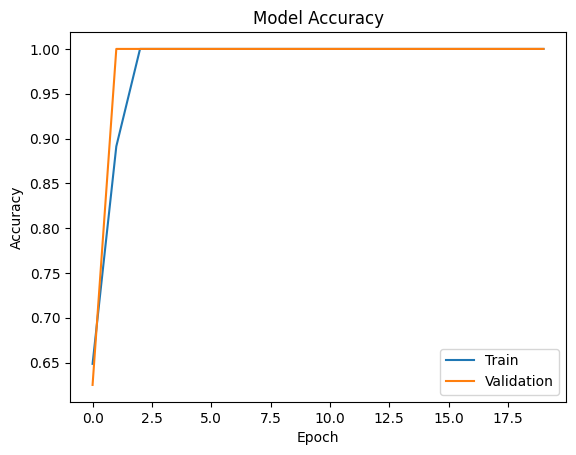

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()